In [1]:
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', None)

In [2]:
fin=open("SeriesIDs_English.txt")
lines=fin.readlines()
for line in lines:
    print(line.strip("\n"))

In [15]:
hist={}
for nn,line in enumerate(lines):
    if line[:3] == "SMS" or line[:3] == "SMU":
        ser=line.strip("\n")
        hist[ser]=[]
        if line[5:9] == "0000":
           for mm in range(nn+2,nn+7):
         #    print(lines[mm])
             val=lines[mm].split(" - ")[1].strip("\n")
             hist[ser].append(val)
          # print("---")

In [ ]:
bad=[]
for ser,lst in hist.items():
    if len(lst) > 0:
       print(f"{ser:25s}  {lst[0]:25s}  {lst[2]:10s}  {lst[3]:30s}   {lst[4]:30s} ")
    else:
        bad.append(ser)

In [2]:
df=pd.read_csv("sm.data.6.Colorado",delimiter="\s+")

In [4]:
df.head()

,series_id,year,period,value,footnote_codes
0,SMS08000000000000001,1990,M01,1502.2,NaN
1,SMS08000000000000001,1990,M02,1506.5,NaN
2,SMS08000000000000001,1990,M03,1510.6,NaN
3,SMS08000000000000001,1990,M04,1514.3,NaN
4,SMS08000000000000001,1990,M05,1523.7,NaN


In [3]:
tmp=df[["series_id","value"]].groupby(["series_id"],as_index=False).count().sort_values(by="series_id")

In [ ]:
tmp.head(500)

In [ ]:
year month series U-Lab   U-

In [25]:
tmp = df.loc[(df["series_id"] == "SMS08000000000000001") | (df["series_id"] == "SMU08000000000000001")]

In [26]:
tmp.shape

(1537, 5)

<Axes: >

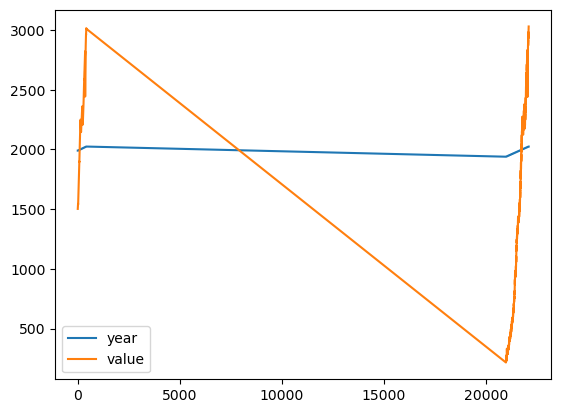

In [27]:
tmp.plot()

In [34]:
tmpS = tmp.loc[tmp["series_id"] == "SMS08000000000000001"]
tmpU = tmp.loc[tmp["series_id"] == "SMU08000000000000001"]


In [36]:
tmpN=tmpU.merge(tmpS,on="series_id",how="left")

In [42]:
tmpN.head()
tmpN.drop(["year_y","period_y"],inplace=True,axis=1)

In [43]:
tmpN.rename(columns={"year_

,series_id,year_x,period_x,value_x,footnote_codes_x,value_y,footnote_codes_y
0,SMU08000000000000001,1939,M01,217.2,NaN,NaN,NaN
1,SMU08000000000000001,1939,M02,216.8,NaN,NaN,NaN
2,SMU08000000000000001,1939,M03,220.1,NaN,NaN,NaN
3,SMU08000000000000001,1939,M04,224.9,NaN,NaN,NaN
4,SMU08000000000000001,1939,M05,232.2,NaN,NaN,NaN
...,...,...,...,...,...,...,...
1112,SMU08000000000000001,2024,M08,3005.0,NaN,NaN,NaN
1113,SMU08000000000000001,2024,M09,3009.6,NaN,NaN,NaN
1114,SMU08000000000000001,2024,M10,3023.4,NaN,NaN,NaN
1115,SMU08000000000000001,2024,M11,3016.6,NaN,NaN,NaN


In [13]:
invt={}
years={}
for indx,row in df.iterrows():
    ser=row["series_id"]
    tp = ser[2:3]
    if tp not in years:
        years[tp]={}
    year=int(row["year"])
    years[tp][year]=1
    month=int(row["period"].replace("M","") )
    if ser not in invt:
        invt[ser]={}
    if year not in invt[ser]:
        invt[ser][year]={}
    if month not in invt[ser][year]:
        invt[ser][year][month]=0
    invt[ser][year][month]+=1
        


In [26]:
startYears={}
endYears={}
stats={}
summary={}
for tp in years:
    startYears[tp]=min(years[tp])
    endYears[tp]=max(years[tp])
    


for ser,dct in invt.items():
 #   print(ser)
    tp=ser[2:3]
    sers=ser[3:]
    if tp not in stats:
        stats[tp]={}
    if ser not in stats[tp]:
        stats[tp][ser]={}
        stats[tp][ser]['yrmos']=[]
        stats[tp][ser]['gaps']=[]
    if tp not in summary:
        summary[tp]={} 
    if sers not in summary[tp]:
        summary[tp][sers]={}
    for year in range(startYears[tp],endYears[tp]+1):
   #     print(f"{year:4d}",end="")
        if year in dct:    
            nmos=0
            for mon in range(1,14):
                if mon in dct[year]:
                    cnt=str(dct[year][mon])
                    mm=str(mon).zfill(2)
                    yrmo = int(f"{year}{mm}")
                    stats[tp][ser]['yrmos'].append(yrmo)   
                    nmos+=1
                else:
                    cnt = " "
                    stats[tp][ser]['gaps'].append(yrmo)
 #                   if mon == 12:
 #                       print("Series ",year,ser)
            summary[tp][sers][year]=nmos
  #             print(f" {cnt:1s}",end="")
   #         print("")
    #    else:
    #        print("             ")
                
            

In [23]:
summary.keys()

dict_keys(['S', 'U'])

In [ ]:
for ser,dct in sorted(summary["S"].items()):
    print(ser,dct)
    # if ser in summary["S"]:
    #    print(ser,dct)
    #    print(ser,summary["S"][ser])
    #    print()

In [ ]:
for ser,dct in stats["U"].items():
    startu=min(dct['yrmos'])
    endu=max(dct['yrmos'])
    s2=ser[0:2] + "S" + ser[3:]
    if s2 in stats["S"]:
       starts=min(stats["S"][s2]['yrmos'])
       ends=max(stats["S"][s2]['yrmos'])
    else:
        starts="      "
        ends="      "            
    if isinstance(starts,int):  
        print(ser,startu,endu,starts,ends)


for ser,dct in stats["U"].items():
    startu=min(dct['yrmos'])
    endu=max(dct['yrmos'])
    s2=ser[0:2] + "S" + ser[3:]
    if s2 in stats["S"]:
       starts=min(stats["S"][s2]['yrmos'])
       ends=max(stats["S"][s2]['yrmos'])
    else:
        starts="      "
        ends="      "            
    if isinstance(starts,str):  
        print(ser,startu,endu,starts,ends)

In [93]:
for tp,dct in stats.items():
    for ser,lst in dct.items():
        print(tp,ser,lst['gaps'])

S SMS08000000000000001 [199012, 199112, 199212, 199312, 199412, 199512, 199612, 199712, 199812, 199912, 200012, 200112, 200212, 200312, 200412, 200512, 200612, 200712, 200812, 200912, 201012, 201112, 201212, 201312, 201412, 201512, 201612, 201712, 201812, 201912, 202012, 202112, 202212, 202312, 202412]
S SMS08000000000000026 [202412, 202412, 202412, 199012, 199112, 199212, 199312, 199412, 199512, 199612, 199712, 199812, 199912, 200012, 200112, 200212, 200312, 200412, 200512, 200612, 200712, 200812, 200912, 201012, 201112, 201212, 201312, 201412, 201512, 201612, 201712, 201812, 201912, 202012, 202112, 202212, 202312, 202412]
S SMS08000000500000001 [199012, 199112, 199212, 199312, 199412, 199512, 199612, 199712, 199812, 199912, 200012, 200112, 200212, 200312, 200412, 200512, 200612, 200712, 200812, 200912, 201012, 201112, 201212, 201312, 201412, 201512, 201612, 201712, 201812, 201912, 202012, 202112, 202212, 202312, 202412]
S SMS08000000500000026 [202412, 202412, 202412, 199012, 199112, 

period
M05    13698
M04    13698
M08    13698
M07    13698
M06    13698
M10    13698
M11    13698
M12    13698
M09    13698
M02    13689
M03    13689
M01    13689
M13    11574
Name: count, dtype: int64

In [55]:
max(years.keys())
min(years.keys())


1939

<Axes: xlabel='year'>

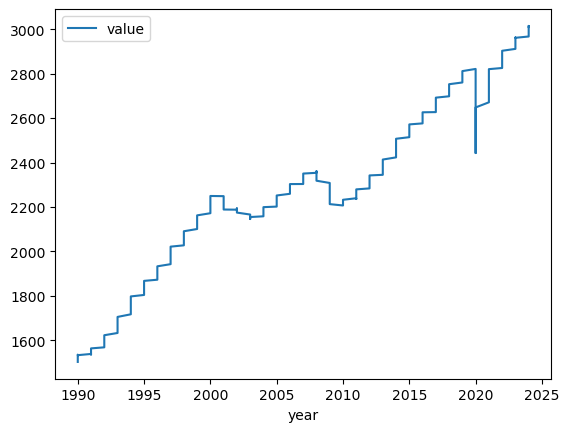

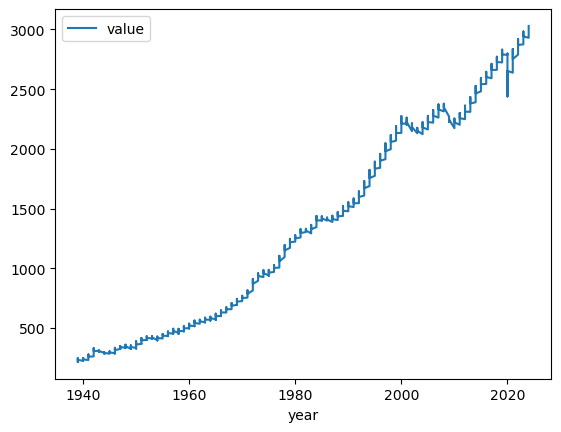

In [31]:
tmp.loc[tmp["series_id"] == "SMS08000000000000001"].plot(x="year",y="value")
tmp.loc[tmp["series_id"] == "SMU08000000000000001"].plot(x="year",y="value")


In [ ]:
df.loc[df["series_id"] == "SMS08000000000000001"].plot(x="year",y="value")

In [ ]:
a = 